In [355]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap
%matplotlib inline

In [356]:
# Statistics
models = ['NADE', 'ED-Tr.', 'D-Tr.', 'MOE']
colors = ['red', 'blue', 'cyan', 'purple']
fmt1 = ['o','*', 's', '^']
fmt2 = ['D', 'v', '>', 'v']

In [357]:
def graph_plot_means(fn, 
                     models, 
                     x, 
                     colors, 
                     central_points_1, 
                     errors_1, 
                     er_label1, 
                     central_points_2, 
                     errors_2, 
                     er_label2, 
                     y_ticks, 
                     y_label, 
                     title, 
                     fmt='*', 
                     y_top=0.5,
                     y_bot=0.25):
    # Set the figure size for two-column format with extra height for title/legend
    fig, ax = plt.subplots(figsize=(5, 4.5))
    
    length_graph = len(models)*3
    null1_pos = [0.1 for _ in range(length_graph)]
    null1_neg = [-0.1 for _ in range(length_graph)]
    null2_pos = [0.5 for _ in range(length_graph)]
    null2_neg = [-0.5 for _ in range(length_graph)]
    
    # Increase line widths and marker sizes for better visibility
    for i, m in enumerate(models):
        ax.errorbar(i*3, central_points_1[i], yerr=errors_1[i], fmt='o', color=colors[i], 
                   capsize=4, markersize=8, elinewidth=1.5, 
                   label=m+' '+er_label1, capthick=1.5)
        ax.errorbar((i*3)+1, central_points_2[i], yerr=errors_2[i], fmt=fmt, color=colors[i], 
                   capsize=4, markersize=10, elinewidth=1.5, 
                   label=m+' '+er_label2, capthick=1.5)

    # Make dashed lines more visible
    ax.plot(x, null1_pos, 'y--', linewidth=1.5, alpha=0.8)
    ax.plot(x, null1_neg, 'y--', linewidth=1.5, alpha=0.8)
    ax.plot(x, null2_pos, 'y--', linewidth=1.5, alpha=0.4)
    ax.plot(x, null2_neg, 'y--', linewidth=1.5, alpha=0.4)

    # Adjust text sizes for readability
    ax.set_xticks([])
    ax.set_yticks(y_ticks)
    ax.tick_params(axis='y', labelsize=12)
    wrapped_y_label = '\n'.join(textwrap.wrap(y_label, width=40))
    ax.set_ylabel(wrapped_y_label, fontsize=13, fontweight='bold')
    ax.set_xlabel(' ', fontsize=13)
    # Wrap long titles
    wrapped_title = '\n'.join(textwrap.wrap(title, width=40))
    ax.set_title(wrapped_title, fontsize=13, fontweight='bold', pad=10)
    
    # Optimize legend with better positioning and shorter labels
    handles, labels = ax.get_legend_handles_labels()
    # Shorten legend labels by removing redundant words
    shortened_labels = [label.replace(' Permutations', '').replace(' Random', ' Rand.') for label in labels]
    legend = ax.legend(handles, shortened_labels, 
                      loc='upper center', ncol=2, fontsize=11)
    

    # Adjust plot margins
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min-y_bot, y_max+y_top)
    
    # Increase DPI for better quality
    plt.savefig(fn + '.pdf', dpi=900, format='pdf', 
                bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.close(fig)

In [358]:
def graph_plot_var(fn, models, x, colors, central_points_1, errors_1, 
                  er_label1, central_points_2, errors_2, er_label2, 
                  y_ticks, y_label, title, fmt='*', y_top=2.5):
    
    # Set the figure size for two-column format
    fig, ax = plt.subplots(figsize=(5, 4))
    length_graph = len(models)*3

    # Increase line widths and marker sizes for better visibility
    for i, m in enumerate(models):
        ax.errorbar(i*3, central_points_1[i], yerr=errors_1[i], fmt='o', color=colors[i], 
                   capsize=4, markersize=8, elinewidth=1.5, 
                   label=m+' '+er_label1, capthick=1.5)
        ax.errorbar((i*3)+1, central_points_2[i], yerr=errors_2[i], fmt=fmt, color=colors[i], 
                   capsize=4, markersize=10, elinewidth=1.5, 
                   label=m+' '+er_label2, capthick=1.5)

    nullvar_pos = [1.0 for _ in range(length_graph)]
    ax.plot(x, nullvar_pos, 'y--', linewidth=1.5, alpha=0.8)

    # Adjust text sizes for readability
    ax.set_xticks([])
    ax.set_yticks(y_ticks)
    ax.tick_params(axis='y', labelsize=12)
    wrapped_ylabel = '\n'.join(textwrap.wrap(y_label, width=40))
    ax.set_ylabel(wrapped_ylabel, fontsize=13, fontweight='bold')
    ax.set_xlabel(' ', fontsize=16)
    wrapped_title = '\n'.join(textwrap.wrap(title, width=40))
    ax.set_title(wrapped_title, fontsize=13, fontweight='bold', pad=10)
    
    # Optimize legend
    ax.legend(loc='upper center', ncol=2, fontsize=11)

    # Adjust plot margins
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min-0.5, y_max+y_top)
    
    # Increase DPI for better quality
    plt.savefig(fn + '.pdf', dpi=900, format='pdf', 
                bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.close(fig)

In [359]:
cis_perm = [(-0.09800717948369757, 0.08824550699028373), 
       (-0.0730606755527336, -0.004635752881748424), 
       (-0.4987478959606886, -0.40051865730690805), 
       (0.033068241451102605, 0.11016413192687854)]

cis_null = [(-0.1352584558025073, 0.08598271568551102),
            (-0.339874591942137, 0.31369153313703224),
            (-0.38854888798385684, 0.2817820487631419),
            (-0.4135138574446752, 0.23650790164887953)]

central_points_perm = [(ci[0] + ci[1]) / 2 for ci in cis_perm]
errors_perm = [(ci[1] - ci[0]) / 2 for ci in cis_perm]
central_points_null = [(ci[0] + ci[1]) / 2 for ci in cis_null]
errors_null = [(ci[1] - ci[0]) / 2 for ci in cis_null]
x = [i for i in range(len(models)*3)]
er_label1 = 'Permutations'
er_label2 = 'Random'
y_ticks = [-0.5, -0.1, 0.0, 0.1, 0.5]
y_label = "Mean Difference Log Probabilities"
title = "0.95 Confidence Intervals Mean Log Differences Permutations"
fn = 'mean-perms-train'


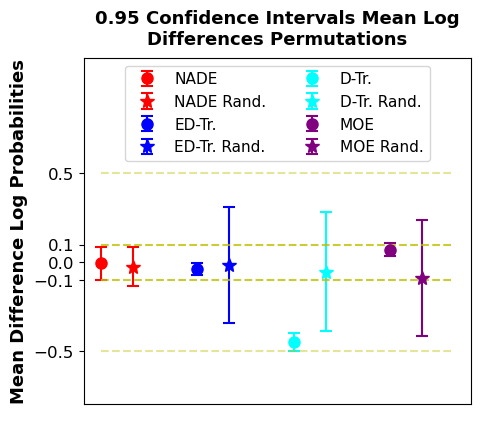

In [360]:
graph_plot_means(fn, models=models, x=x, colors=colors, central_points_1=central_points_perm, errors_1=errors_perm, er_label1=er_label1, 
                 central_points_2=central_points_null, errors_2=errors_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, title=title,
                 y_top=0.6)

In [361]:
cis_var_models = [(1.836336344841362, 1.968225408481784),
                  (0.6746274363738786, 0.7230804232896146),
                  (0.9684795665550395, 1.03803755550769),
                  (0.7601178184259567, 0.8147108822784614)]
cis_var_null = [(2.18130117675099, 2.337966250950287),
                (6.4437579503459785, 6.906560532663803),
                (6.60904862916986, 7.083722692940311),
                (6.408812692900189, 6.869105442367323)]

central_points_var_model = [(ci[0] + ci[1]) / 2 for ci in cis_var_models]
errors_var_model = [(ci[1] - ci[0]) / 2 for ci in cis_var_models]
central_points_var_null = [(ci[0] + ci[1]) / 2 for ci in cis_var_null]
errors_var_null = [(ci[1] - ci[0]) / 2 for ci in cis_var_null]
y_ticks= [i for i in range(10)]
er_label1 = ''
er_label2 = 'Rand.'
y_label = "Variance Difference Log Probabilities"
title = "0.95 Confidence Intervals Variance Log Differences Permutations"
fn = 'var-perms-train'

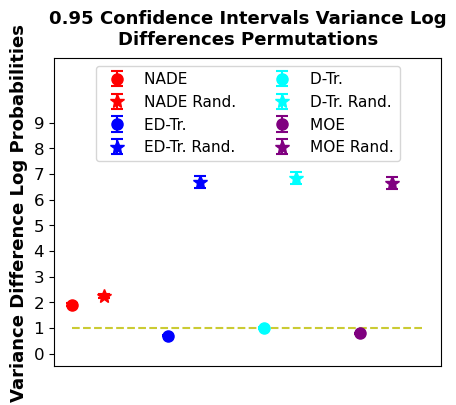

In [362]:
graph_plot_var(fn, models=models, x=x, colors=colors, central_points_1=central_points_var_model, errors_1=errors_var_model, er_label1=er_label1, 
               central_points_2=central_points_var_null, errors_2=errors_var_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, title=title)

In [363]:
cis_mean_notrain_model = [(-0.09942722179502403, -0.04538656262603816),
                          (-0.14979505719982333, -0.010868830465853255),
                          (-0.15187910830237655, 0.047491481224736815),
                          (-0.5225573895550596, -0.1528708783567567)]
cis_mean_notrain_null =[(-0.032401095445650833, 0.022386867951718584),
                        (-0.19739121516646635, 0.4237180339250812),
                        (-0.39299567395006746, 0.26853475297883084),
                        (-0.2136241081557821, 0.813343086275315)]

central_points_mean_notrain_model = [(ci[0] + ci[1]) / 2 for ci in cis_mean_notrain_model]
errors_mean_notrain_model = [(ci[1] - ci[0]) / 2 for ci in cis_mean_notrain_model]
central_points_mean_notrain_null = [(ci[0] + ci[1]) / 2 for ci in cis_mean_notrain_null]
errors_mean_notrain_null = [(ci[1] - ci[0]) / 2 for ci in cis_mean_notrain_null]
x = [i for i in range(len(models)*3)]
er_label1 = 'NT'
er_label2 = 'NT Rand.'
y_ticks = [-0.5, -0.1, 0.0, 0.1, 0.5]
y_label = "Mean Difference Log Probabilities"
title = "0.95 Confidence Intervals Mean Log Differences Tr/No-Tr Models"
fn = 'mean-perms-notrain'

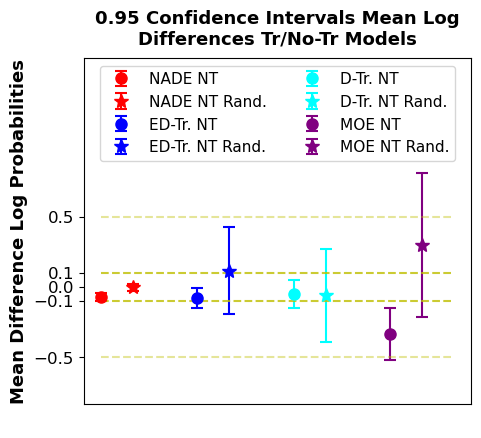

In [364]:
graph_plot_means(fn, models=models, x=x, colors=colors, central_points_1=central_points_mean_notrain_model, errors_1=errors_mean_notrain_model, er_label1=er_label1, 
                 central_points_2=central_points_mean_notrain_null, errors_2=errors_mean_notrain_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, title=title,
                 y_top=0.75)

In [365]:
cis_var_models_notrain = [(0.5328074907797709, 0.5710747075981677),
                          (1.3697267096273509, 1.4681030085463997),
                          (1.9656707592898588, 2.1068488591496055),
                          (3.644880455487453, 3.906662493242113)]

central_points_var_model_notrain = [(ci[0] + ci[1]) / 2 for ci in cis_var_models_notrain]
errors_var_model_notrain = [(ci[1] - ci[0]) / 2 for ci in cis_var_models_notrain]
x = [i for i in range(len(models)*3)]
er_label1 = 'Trained'
er_label2 = 'No Trained'
y_ticks= [i for i in range(5)]
y_label = "Variance Difference Log Probabilities"
title = "0.95 Confidence Intervals Variance Log Differences Tr/No-Tr Models"
fn = 'var-perms-notrain'

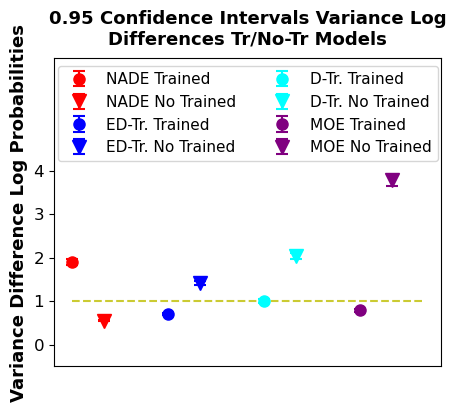

In [366]:
graph_plot_var(fn, models=models, x=x, colors=colors, central_points_1=central_points_var_model, errors_1=errors_var_model, er_label1=er_label1, 
               central_points_2=central_points_var_model_notrain, errors_2=errors_var_model_notrain, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, 
               title=title, fmt='v')

In [367]:
colors = ['blue', 'cyan', 'purple']
cis_diff_train_model = [(9.56646433681422, 9.92090012299316),
                        (9.19922816787868, 9.556625840970291),
                        (9.690797949625797, 10.036685478686554)]
cis_diff_train_null =[(9.428971923435832, 10.00323437792683),
                      (9.103250048699135, 9.673966496813978),
                      (9.618693076747183, 10.19206425126155)]

central_points_diff_train_model = [(ci[0] + ci[1]) / 2 for ci in cis_diff_train_model]
errors_diff_train_model = [(ci[1] - ci[0]) / 2 for ci in cis_diff_train_model]
central_points_diff_train_null = [(ci[0] + ci[1]) / 2 for ci in cis_diff_train_null]
errors_diff_train_null = [(ci[1] - ci[0]) / 2 for ci in cis_diff_train_null]
x = [i for i in range(len(models[1:])*3)]
er_label1 = 'Orig.'
er_label2 = 'Rand.'
y_ticks = [i - 1.0 for i in range(12)]
y_label = "Mean Difference Log Probabilities"
title = "0.95 Confidence Intervals Mean Log Differences Interventional and Model Distribution"
fn = 'dummy'

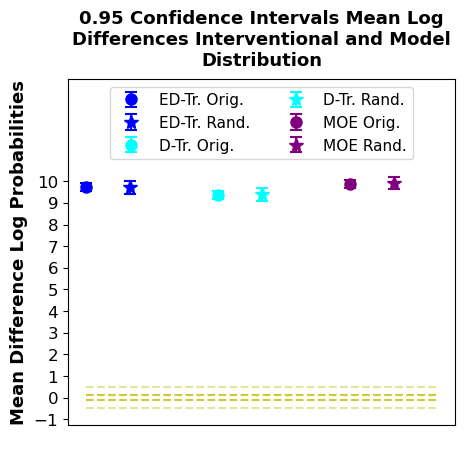

In [368]:
graph_plot_means(fn, models=models[1:], x=x, colors=colors, central_points_1=central_points_diff_train_model, errors_1=errors_diff_train_model, er_label1=er_label1, 
                 central_points_2=central_points_diff_train_null, errors_2=errors_diff_train_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, 
                 title=title, y_top=4.0)

In [369]:
cis_diff_train_model = [(13.703671808870705, 13.85740588975127),
                        (13.469991916089917, 13.61988208829639),
                        (13.725442166445317, 13.88619491700983)]
cis_diff_train_null =[(13.46864828921747, 14.118612468209616),
                      (13.266798550370218, 13.929842293236803),
                      (13.574295012059634, 14.214348027191305)]

central_points_diff_train_model = [(ci[0] + ci[1]) / 2 for ci in cis_diff_train_model]
errors_diff_train_model = [(ci[1] - ci[0]) / 2 for ci in cis_diff_train_model]
central_points_diff_train_null = [(ci[0] + ci[1]) / 2 for ci in cis_diff_train_null]
errors_diff_train_null = [(ci[1] - ci[0]) / 2 for ci in cis_diff_train_null]
x = [i for i in range(len(models[1:])*3)]
er_label1 = 'Orig.'
er_label2 = 'Random'
y_ticks = [i - 1.0 for i in range(17)]
y_label = "Mean Difference Log Probabilities"
title = "0.95 Confidence Intervals Mean Log Differences Probabilities"
fn = 'mean-dist-train'


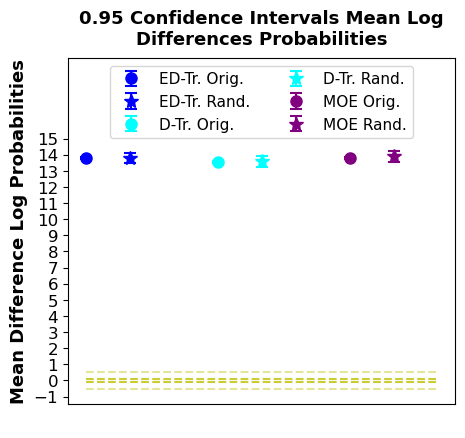

In [370]:
graph_plot_means(fn, models=models[1:], x=x, colors=colors, central_points_1=central_points_diff_train_model, errors_1=errors_diff_train_model, er_label1=er_label1, 
                 central_points_2=central_points_diff_train_null, errors_2=errors_diff_train_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, 
                 title=title, y_top=5.0)

In [371]:
order_magnitude = [1e8, 1e9, 1e10]

# Transformer data
transformer_dist_mean_distance = [9.73804, 13.802, 14.4951]
transformer_dist_mean_null = [-49.6747, -72.3364, -63.6987]
transformer_dist_std_distance = [2.17087, 1.72716, 1.61256]
transformer_dist_std_null = [8.38957, 8.58792, 11.5375]

# Decoder-Transformer data
decoder_dist_mean_distance = [4.62269, 13.7415, 14.3711]
decoder_dist_mean_null = [-66.5409, -60.0026, -83.5586]
decoder_dist_std_distance = [2.82049, 1.54672, 1.53648]
decoder_dist_std_null = [6.9843, 8.0612, 10.0432]

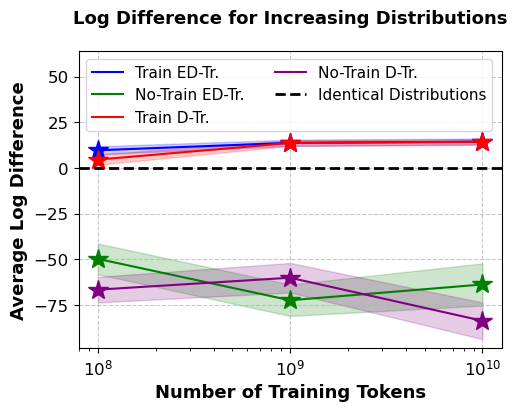

In [372]:
# Create the plot
fig, ax = plt.subplots(figsize=(5,4), constrained_layout=True)
#plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.15)
ax.grid(True, linestyle='--', alpha=0.7)

# Plot Transformer data
ax.plot(order_magnitude, transformer_dist_mean_distance, color='blue', label='Train ED-Tr.')
ax.fill_between(order_magnitude, 
                 np.array(transformer_dist_mean_distance) - np.array(transformer_dist_std_distance),
                 np.array(transformer_dist_mean_distance) + np.array(transformer_dist_std_distance),
                 alpha=0.2, color='blue')
ax.plot(order_magnitude, transformer_dist_mean_null, color='green', label='No-Train ED-Tr.')
ax.fill_between(order_magnitude, 
                 np.array(transformer_dist_mean_null) - np.array(transformer_dist_std_null),
                 np.array(transformer_dist_mean_null) + np.array(transformer_dist_std_null),
                 alpha=0.2, color='green')

# Plot Decoder-Transformer data
ax.plot(order_magnitude, decoder_dist_mean_distance, color='red', label='Train D-Tr.')
ax.fill_between(order_magnitude, 
                 np.array(decoder_dist_mean_distance) - np.array(decoder_dist_std_distance),
                 np.array(decoder_dist_mean_distance) + np.array(decoder_dist_std_distance),
                 alpha=0.2, color='red')
ax.plot(order_magnitude, decoder_dist_mean_null, color='purple', label='No-Train D-Tr.')
ax.fill_between(order_magnitude, 
                 np.array(decoder_dist_mean_null) - np.array(decoder_dist_std_null),
                 np.array(decoder_dist_mean_null) + np.array(decoder_dist_std_null),
                 alpha=0.2, color='purple')

# Add stars at each point
for x, y in zip(order_magnitude, transformer_dist_mean_distance):
    ax.plot(x, y, 'b*', markersize=15)
for x, y in zip(order_magnitude, transformer_dist_mean_null):
    ax.plot(x, y, 'g*', markersize=15)
for x, y in zip(order_magnitude, decoder_dist_mean_distance):
    ax.plot(x, y, 'r*', markersize=15)
for x, y in zip(order_magnitude, decoder_dist_mean_null):
    ax.plot(x, y, 'purple', marker='*', markersize=15)

# Add horizontal line at y=0 for identical distributions
ax.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Identical Distributions')

# Adjust y-axis limits
y_min = min(min(transformer_dist_mean_null), min(decoder_dist_mean_null))
y_max = max(max(transformer_dist_mean_distance), max(decoder_dist_mean_distance))
y_range = y_max - y_min
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.25 * y_range)

# Customize the plot
ax.set_xscale('log')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Number of Training Tokens', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Log Difference', fontsize=13, fontweight='bold')
title = 'Log Difference for Increasing Distributions'
wrapped_title = '\n'.join(textwrap.wrap(title, width=80))
ax.set_title(wrapped_title, fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper left', ncol=2, fontsize=11)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min-5, y_max+25.0)

# Show the plot
#plt.tight_layout()
fn = 'increasing_dist'
plt.savefig(fn + '.pdf', dpi=900, format='pdf', bbox_inches='tight')
plt.show()
plt.close(fig)